Plot error curves of the target reaching experiment.

In [17]:
import sys
sys.path.insert(1, 'E:/OneDrive - UC San Diego/UCSD/Lab/Catheter/diff_catheter/scripts')

import cv2
import matplotlib.pyplot as plt
import pickle
from matplotlib.lines import Line2D

from utils import *
import camera_settings
import path_settings

In [18]:
exp_name = 'EXP003'
i = 7

data_alias = 'D' + str(0).zfill(2)
method_dir = os.path.join(path_settings.results_dir, exp_name)
data_dir = os.path.join(method_dir, data_alias + '_' + str(i).zfill(4))
print(data_dir)

E:/OneDrive - UC San Diego/UCSD/Lab/Catheter/diff_catheter/results\EXP003\D00_0007


In [19]:
params_save_path = data_dir + '/' + 'loss.pkl'
print(params_save_path)

E:/OneDrive - UC San Diego/UCSD/Lab/Catheter/diff_catheter/results\EXP003\D00_0007/loss.pkl


In [20]:
with open(params_save_path, 'rb') as file:
    params = pickle.load(file)
print(params)
loss = [x * 1000 for x in params]

[0.14557540246316156, 0.0028845223043704976, 0.0007375163293659604, 0.0007076010349762135, 0.0008226944536615759, 0.0011418285448343466, 0.000794318306531912, 0.0011280027814016547, 0.0008035843262009009, 0.0006702481022513523, 0.000925068654916115]


In [43]:
def plot_3d_end_effector_loss(d3d_end_effector_loss_history, full_path=None, show=True):
    iterations_x_axis_3d = list(range(len(d3d_end_effector_loss_history)))
    fig = plt.figure(dpi=300)
    ax = fig.add_subplot(111)
    fig.suptitle('3D Shape Loss History')
    ax.plot(iterations_x_axis_3d, d3d_end_effector_loss_history, marker='o', markersize=4)
    ax.set_xlabel('Iterations')
    ax.set_ylabel('Error (mm)')
    ax.set_xlim([0, len(d3d_end_effector_loss_history)-1])
    ax.set_ylim(bottom=0)
    # ax.set_ylim([0, 0.05])
    ax.grid(True)
    # ax.minorticks_on()
    ax.xaxis.set_major_locator(plt.MultipleLocator(1))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(10))
    ax.grid(which='minor', color='lightgray', linestyle='--', linewidth=0.5)
    # ax.set_yscale('log')
    

    if full_path is not None:
        if not os.path.exists(os.path.dirname(full_path)):
            os.makedirs(os.path.dirname(full_path))
        plt.savefig(full_path)

    if show:
        plt.show()
        
    plt.close(fig)

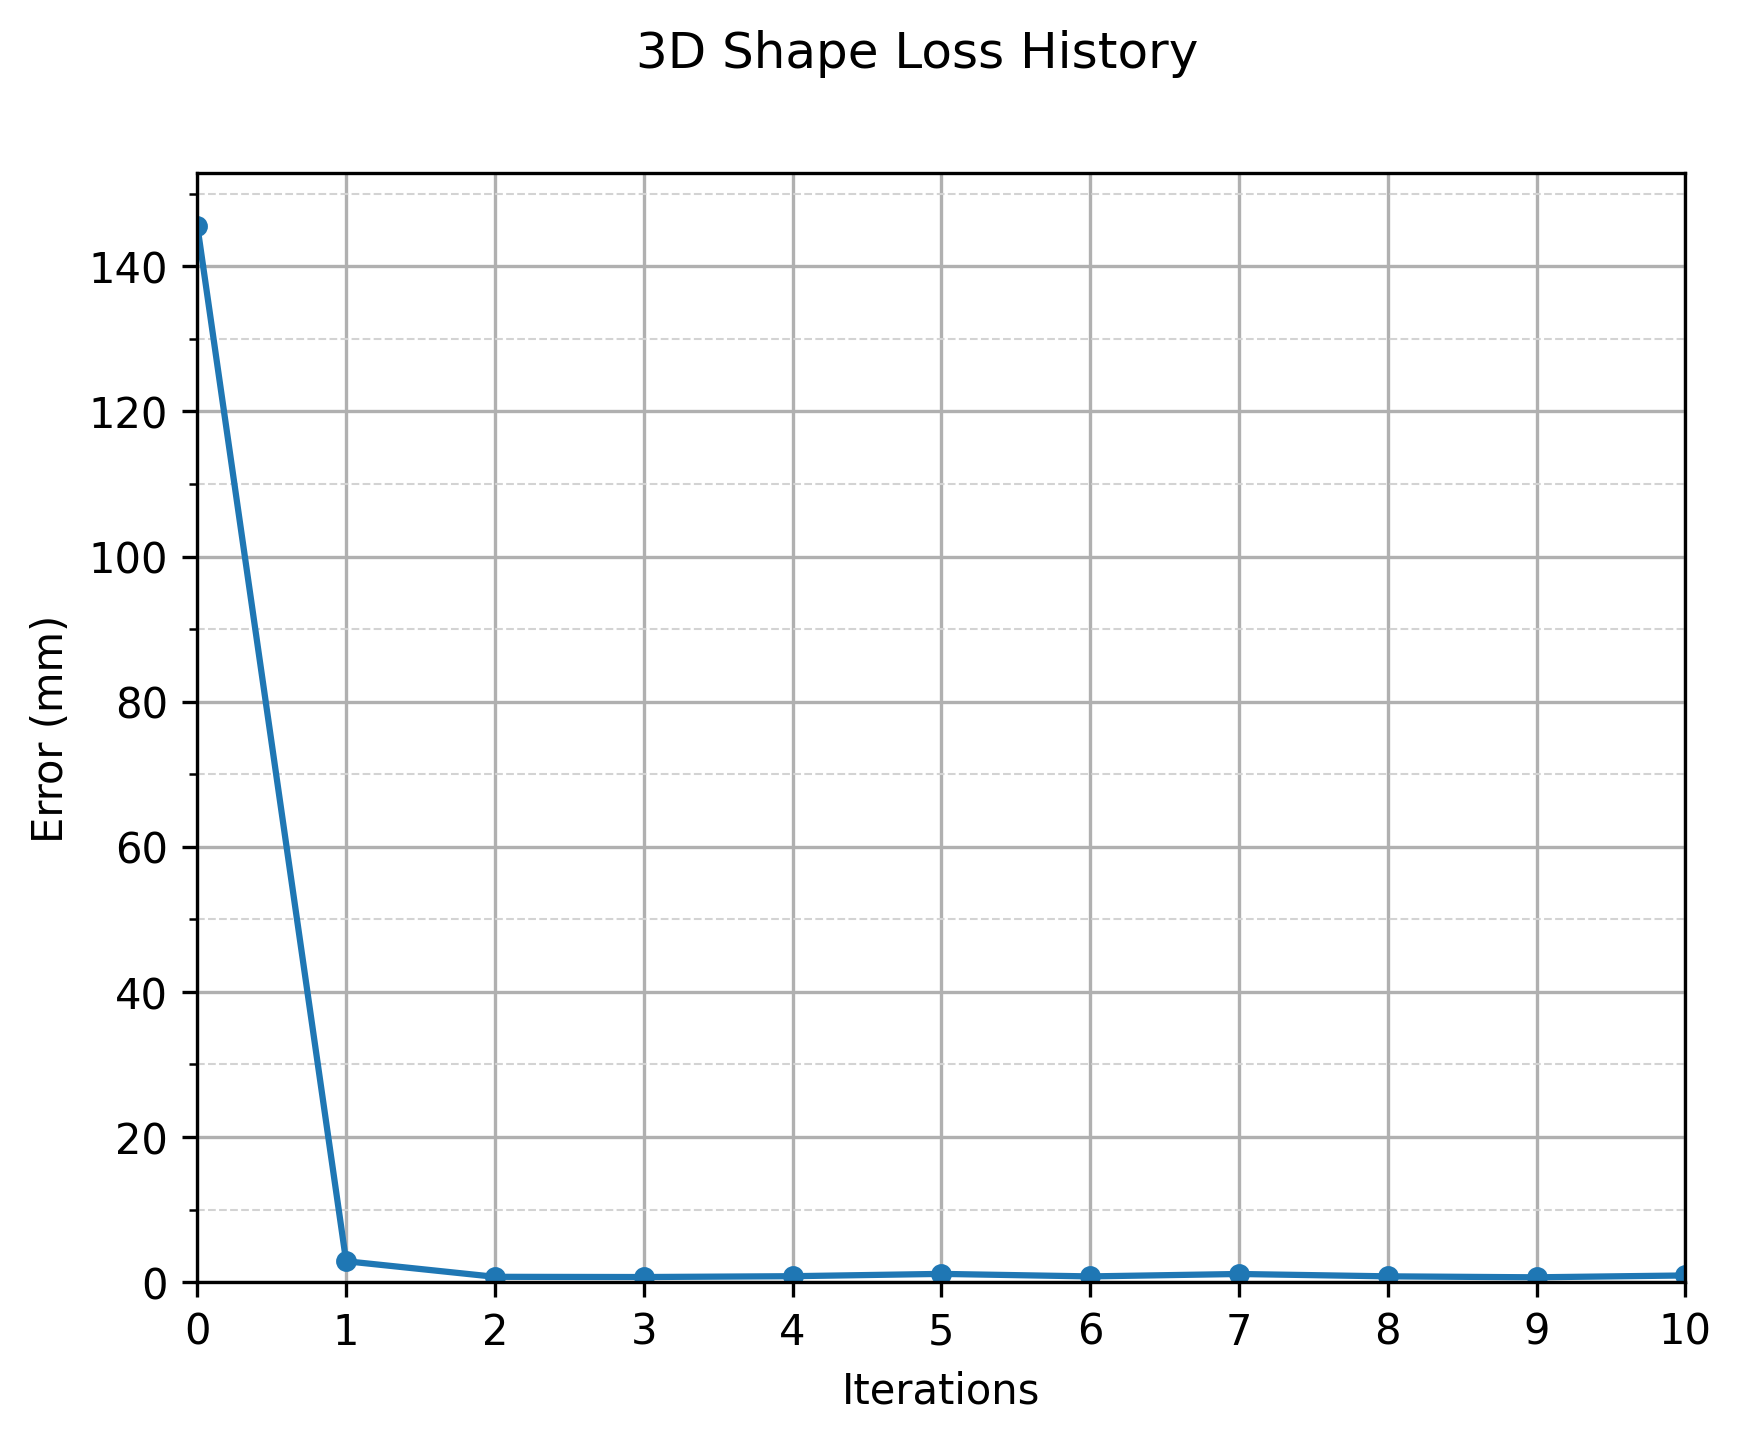

In [44]:
plot_3d_end_effector_loss(loss, show=True)

In [53]:
def plot_tip_loss(loss_tip_distance_history, full_path=None, log_scale=False, show=True):
    iterations_x_axis_loss_tip = list(range(len(loss_tip_distance_history)))
    fig2 = plt.figure(dpi=300)
    ax2 = fig2.add_subplot(111)
    fig2.suptitle('Tip Loss History')
    ax2.plot(iterations_x_axis_loss_tip, loss_tip_distance_history)
    ax2.set_xlabel('Iterations')
    ax2.set_ylabel('Tip Loss')
    ax2.set_xlim([0, len(loss_tip_distance_history)-1])
    ax2.set_ylim(bottom=0)
    if log_scale:
        ax2.set_ylim(bottom=0.1)
        ax2.set_yscale('log')
        ax2.set_ylabel('Tip Loss (log scale)')
    ax2.grid(True)

    if full_path is not None:
        if not os.path.exists(os.path.dirname(full_path)):
            os.makedirs(os.path.dirname(full_path))
        plt.savefig(full_path)

    if show:
        plt.show()
        
    plt.close(fig2)

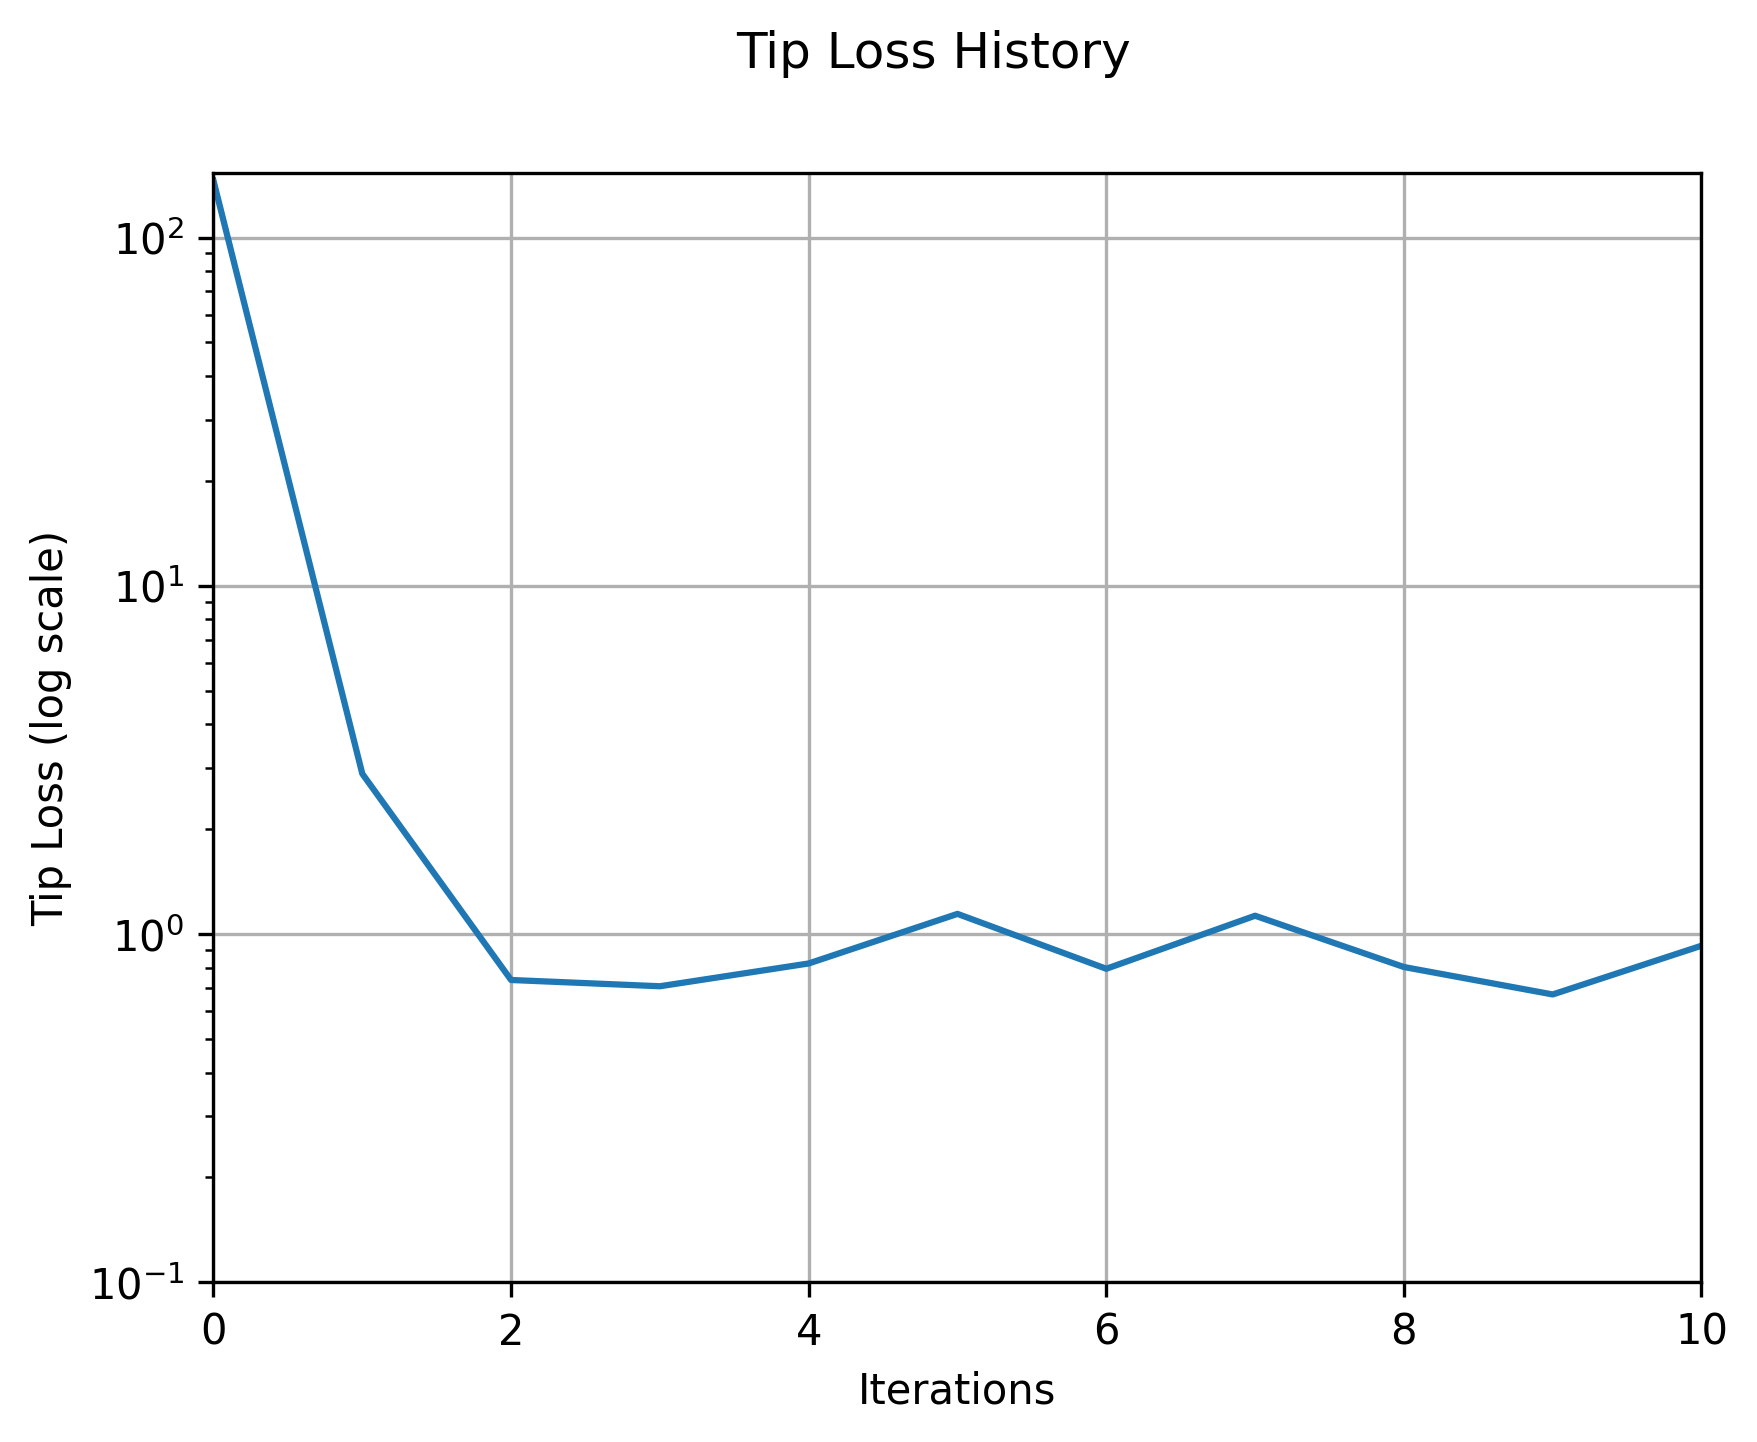

In [54]:
plot_tip_loss(loss, log_scale=True, show=True)